# Ford Focus Price Prediction Using Linear Regression & Scikit-Learn Pipeline

## 1. Libraries and Dependencies Import
*Importing essential data science and machine learning libraries*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn import set_config
set_config(display="text")

## 2. Dataset Loading
*Loading the live Ford Focus used cars dataset from the repository*

In [2]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/usedcars.csv"

df = pd.read_csv(url)
df.head()

,year,model,price,mileage,color,transmission
0,2011,SEL,21992,7413,Yellow,AUTO
1,2011,SEL,20995,10926,Gray,AUTO
2,2011,SEL,19995,7351,Silver,AUTO
3,2011,SEL,17809,11613,Gray,AUTO
4,2012,SE,17500,8367,White,AUTO


## 3. Exploratory Data Analysis Statistical Summary
*Inspecting data types, checking for missing values, and generating descriptive statistics for price and mileage*

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   year          150 non-null    int64 
 1   model         150 non-null    object
 2   price         150 non-null    int64 
 3   mileage       150 non-null    int64 
 4   color         150 non-null    object
 5   transmission  150 non-null    object
dtypes: int64(3), object(3)
memory usage: 7.2+ KB


,year,price,mileage
count,150.000000,150.000000,150.000000
mean,2008.726667,12961.933333,44260.646667
std,2.200966,3122.481735,26982.104322
min,2000.000000,3800.000000,4867.000000
25%,2008.000000,10995.000000,27200.250000
50%,2009.000000,13591.500000,36385.000000
75%,2010.000000,14904.500000,55124.500000
max,2012.000000,21992.000000,151479.000000


## 4. Data Visualization  Price vs. Mileage Relationship
*Generating a scatter plot to visually explore how car price decreases as mileage increases, segmented by production year*

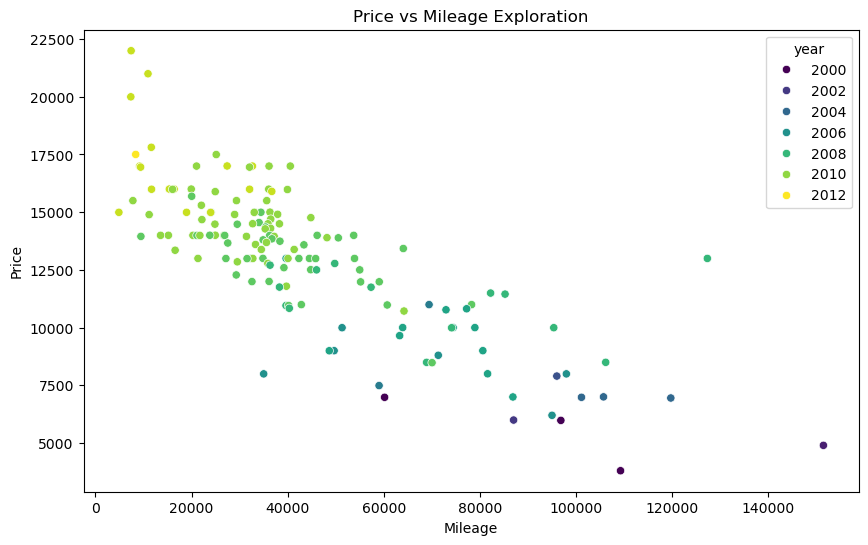

In [4]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='mileage', y='price', data=df, hue='year', palette='viridis')

plt.title('Price vs Mileage Exploration')
plt.xlabel('Mileage')
plt.ylabel('Price')

plt.show()

## 5. Feature and Target Separation
*Splitting the dataset into features (X) and the target variable*

In [5]:
X = df[['year', 'model', 'mileage', 'color', 'transmission']]
y = df['price']

print(X.shape)
print(y.shape)

(150, 5)
(150,)


## 6. Machine Learning Pipeline Construction & Training
*Building a Scikit-Learn Pipeline that combines One Hot Encoding for categorical data and Linear Regression for training*

In [6]:
categorical_features = ['model', 'color', 'transmission']

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['model', 'color',
                                                   'transmission'])])),
                ('model', LinearRegression())])

## 7. Model Evaluation and Validation 
*Evaluating model performance by splitting data into 80% training and 20% testing, and calculating the Mean Absolute Error to measure prediction accuracy*

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

print(f"MAE: {mae:.2f}")

MAE: 1098.13
